# Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (roc_auc_score as ras, accuracy_score, f1_score,
                             precision_score, recall_score, roc_curve, auc,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import os

#  Loading the Dataset

In [4]:
assert os.path.exists("parkinson_disease.csv"), "Dataset not found!"
df = pd.read_csv("parkinson_disease.csv")

# Data Preprocessing - Grouping by ID and Checking for NULLs

In [5]:
df = df.groupby('id').mean().reset_index()
df.drop('id', axis=1, inplace=True)
print("Null values:", df.isnull().sum().sum())
print(f"Original number of features: {df.shape[1]}")

Null values: 0
Original number of features: 754


#  Removing Highly Correlated Features

In [6]:
corr_matrix = df.drop('class', axis=1).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]
df.drop(columns=to_drop, inplace=True)
print(f"Reduced number of features: {df.shape[1]}")

Reduced number of features: 208


# Feature Selection using Chi-Square Test

In [7]:
X = df.drop('class', axis=1)
X_norm = MinMaxScaler().fit_transform(X)
selector = SelectKBest(chi2, k=30)
selector.fit(X_norm, df['class'])
selected_columns = selector.get_support()
filtered_data = X.loc[:, selected_columns]
filtered_data['class'] = df['class']
df = filtered_data
print(df.shape)

(252, 31)


/tmp/ipython-input-7-1820857584.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['class'] = df['class']


# Visualizing Class Distribution (Pie Chart)

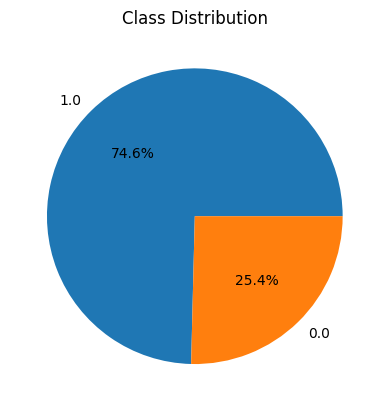

In [8]:
x = df['class'].value_counts()
plt.pie(x.values, labels=x.index, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

# Train-Test Split

In [9]:
features = df.drop('class', axis=1)
target = df['class']
X_train, X_val, Y_train, Y_val = train_test_split(features, target, test_size=0.2, random_state=10)

# 🔁 Handling Class Imbalance with SMOTE

In [10]:
sm = SMOTE(random_state=0)
X_resampled, y_resampled = sm.fit_resample(X_train, Y_train)
print(f"The X shape: {X_resampled.shape}")
print(f"Y value counts: {y_resampled.value_counts()}")

The X shape: (302, 30)
Y value counts: class
1.0    151
0.0    151
Name: count, dtype: int64


# Model Training and Evaluation

In [11]:
models = [
    LogisticRegression(class_weight='balanced', max_iter=1000),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    SVC(kernel='rbf', probability=True)
]

for model in models:
    model.fit(X_resampled, y_resampled)
    print(f"\n{model} Evaluation:")

    train_preds = model.predict(X_resampled)
    val_preds = model.predict(X_val)

    print("Training ROC AUC:", ras(y_resampled, train_preds))
    print("Validation ROC AUC:", ras(Y_val, val_preds))
    print("Accuracy:", accuracy_score(Y_val, val_preds))
    print("Precision:", precision_score(Y_val, val_preds))
    print("Recall:", recall_score(Y_val, val_preds))
    print("F1 Score:", f1_score(Y_val, val_preds))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:40:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



LogisticRegression(class_weight='balanced', max_iter=1000) Evaluation:
Training ROC AUC: 0.7384105960264902
Validation ROC AUC: 0.6998069498069497
Accuracy: 0.7254901960784313
Precision: 0.8484848484848485
Recall: 0.7567567567567568
F1 Score: 0.8

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state

# Confusion Matrix for Each Model

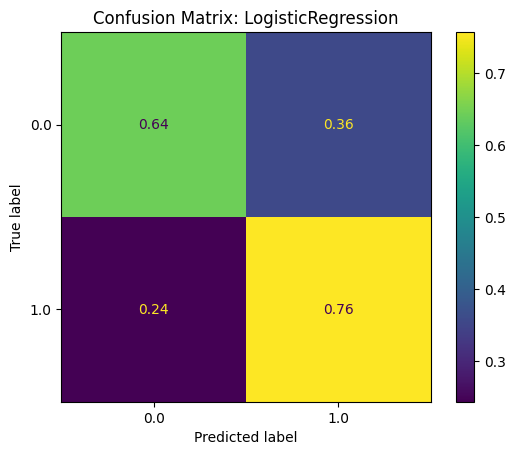

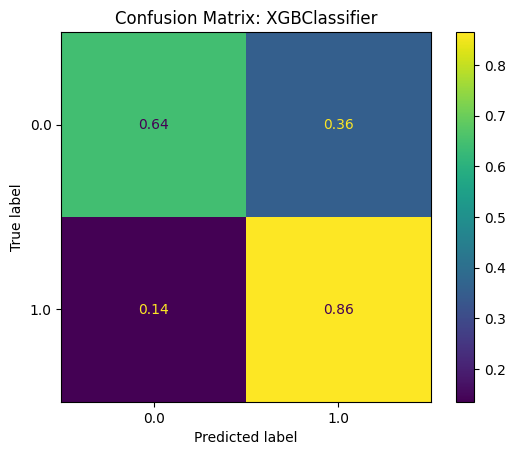

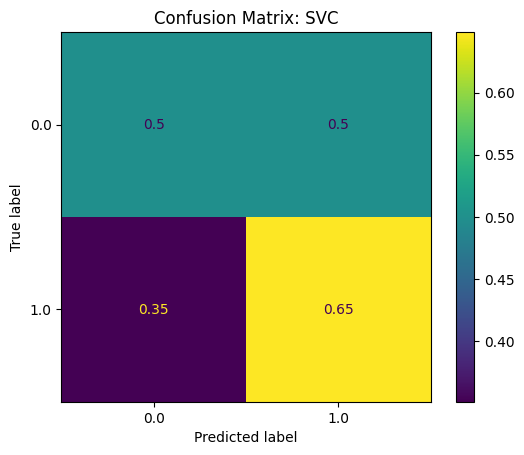

In [12]:
for model in models:
    ConfusionMatrixDisplay.from_estimator(model, X_val, Y_val, normalize='true')
    plt.title(f"Confusion Matrix: {model.__class__.__name__}")
    plt.show()

# ROC Curve for Each Model

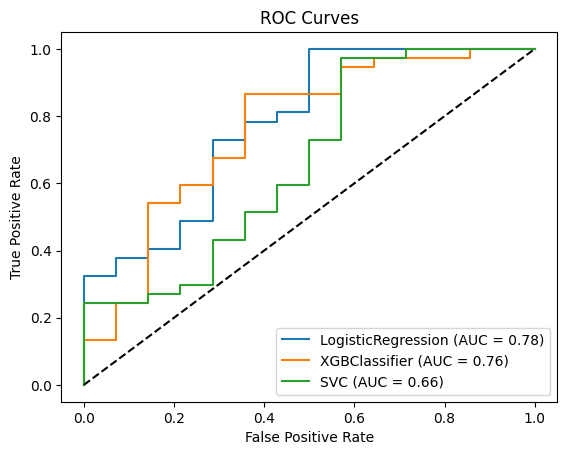

In [13]:
for model in models:
    y_scores = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(Y_val, y_scores)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model.__class__.__name__} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# Classification Report for Logistic Regression

In [14]:
print(classification_report(Y_val, models[0].predict(X_val)))

              precision    recall  f1-score   support

         0.0       0.50      0.64      0.56        14
         1.0       0.85      0.76      0.80        37

    accuracy                           0.73        51
   macro avg       0.67      0.70      0.68        51
weighted avg       0.75      0.73      0.73        51



# Exporting Predictions

In [15]:
pred_df = pd.DataFrame({
    "True": Y_val,
    "Predicted": models[0].predict(X_val)
})
pred_df.to_csv("logreg_predictions.csv", index=False)